# Overview

## Create the simulations

In [ ]:
import numpy as np
from lucifex.io import write
from lucifex.sim import run, xdmf_to_npz, Simulation
from lucifex.plt import (
    plot_colormap, plot_line, get_ipynb_file_name, set_ipynb_variable,
)
from lucifex.utils.npy_utils import as_index
from crocodil.theory.system_a import threshold_rayleigh
from crocodil.dns.system_b import dns_system_b, thermal_rayleigh, SYSTEM_B_REFERENCE

STORE = 1
WRITE = None
DIR_ROOT = f'.figures/{get_ipynb_file_name()}'
NX = set_ipynb_variable('NX', 80)
NY = set_ipynb_variable('NY', 80)
ANIM = set_ipynb_variable('ANIM', False)

theta_neg_opts = (True, False)
simulations: dict[bool, Simulation] = {}

for theta_neg in theta_neg_opts:
    simulations[theta_neg] = dns_system_b(
        store_delta=STORE, 
        write_delta=WRITE, 
        dir_root=DIR_ROOT, 
        dir_uid=True,
    )(
        Nx=NX,
        Ny=NY,
        cell='quadrilateral',
        scaling='advective',
        **SYSTEM_B_REFERENCE,
        theta_neg=theta_neg,
        dt_max=0.1,
        dt_Cu=0.75,
        dt_Cd=0.75,
        dt_Cr=0.1,
        c_stabilization=None,
        theta_stabilization=None,
        c_limits=True,
        theta_limits=True,
        diagnostic=True,
    )
    if theta_neg:
        Ra, Le, gamma, Lx, Ly = (
            float(i) for i in simulations[theta_neg]['Ra', 'Le', 'gamma', 'Lx', 'Ly']
        )
        Ra_thermal = thermal_rayleigh(Ra, Le, gamma)
        Ra_thresh = threshold_rayleigh(Lx, Ly, NX, 2)
        print(f"Ra_solutal = {Ra} , Ra_thermal = {Ra_thermal} , Ra_thresh = {Ra_thresh}")

INFO:root:running build_ext
INFO:root:building 'libffcx_expressions_3b2b53905ac035f806d2d7eaed881483fcc898d5' extension
INFO:root:clang -Wno-unused-result -Wsign-compare -Wunreachable-code -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /Users/George/miniconda3/envs/lucifex/include -fPIC -O2 -isystem /Users/George/miniconda3/envs/lucifex/include -I/Users/George/miniconda3/envs/lucifex/lib/python3.10/site-packages/ffcx/codegeneration -I/Users/George/miniconda3/envs/lucifex/include/python3.10 -c libffcx_expressions_3b2b53905ac035f806d2d7eaed881483fcc898d5.c -o ./libffcx_expressions_3b2b53905ac035f806d2d7eaed881483fcc898d5.o -O2 -g0
INFO:root:clang -bundle -undefined dynamic_lookup -Wl,-rpath,/Users/George/miniconda3/envs/lucifex/lib -L/Users/George/miniconda3/envs/lucifex/lib -Wl,-rpath,/Users/George/miniconda3/envs/lucifex/lib -L/Users/George/miniconda3/envs/lucifex/lib ./libffcx_expressions_3b2b53905ac035f806d2d7eaed881483fcc898d5.o -o ./libffcx_expressions_3b2b53905ac035f806d2d7eaed8814

Ra_solutal = 1000.0 , Ra_thermal = 1000.0 , Ra_thresh = 1800.0


## Run the simulations

In [ ]:
n_stop = set_ipynb_variable('N_STOP', 150)
t_stop = 100.0
dt_init = 1e-6
n_init = 10

for theta_neg, sim in simulations.items():
    run(sim, n_stop=n_stop, t_stop=t_stop, dt_init=dt_init, n_init=n_init, show_progress=True)
    if WRITE: 
        xdmf_to_npz(sim, delete_xdmf=False)
    else:
        write(sim.parameters, sim.parameter_file, sim.dir_path, mode='w')

theta_neg_title = lambda neg: f"$\\theta_0^+={'-1' if neg else '+1'}$"

  0%|          | 0/150 [00:00<?, ?it/s]

## Physical diagnostics

### Solutal and thermal flux

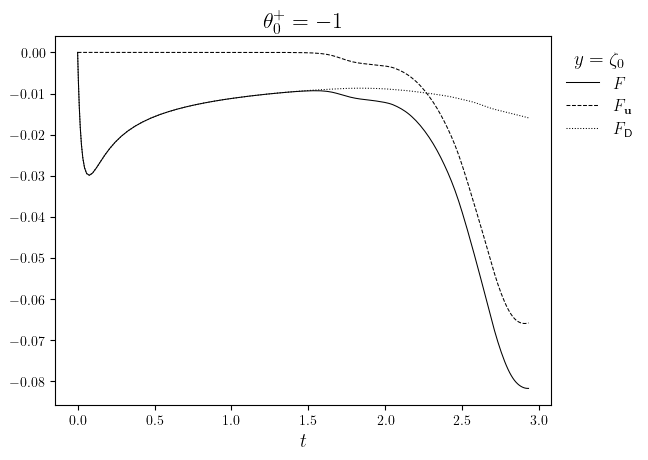

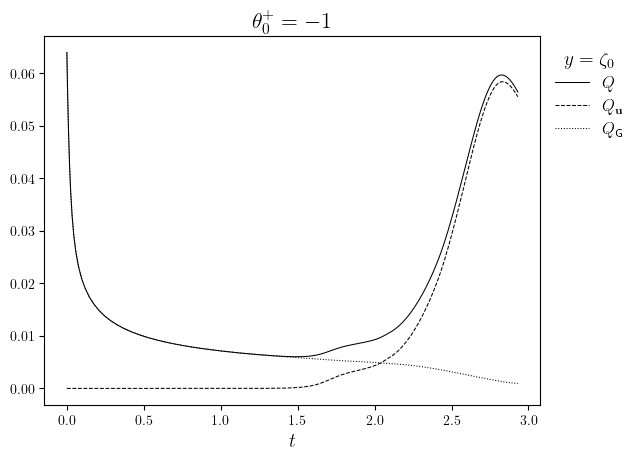

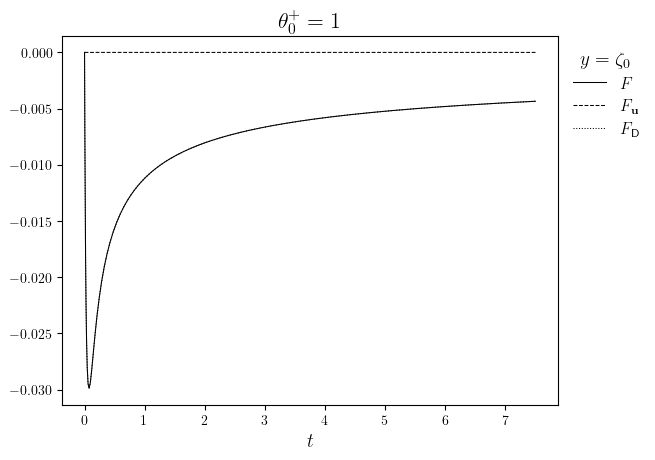

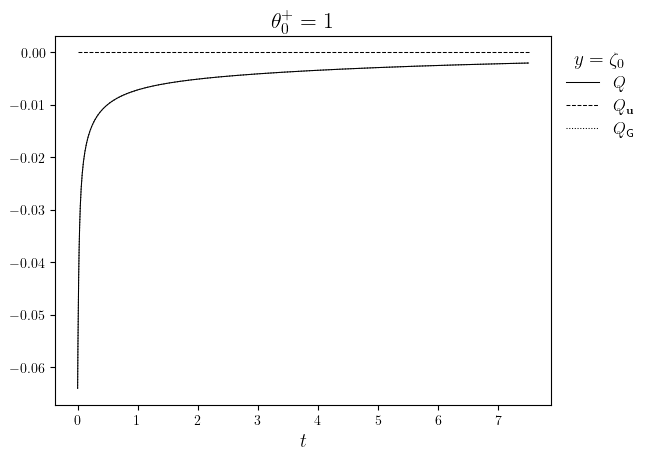

In [ ]:
for theta_neg, sim in simulations.items():
    f, q = sim['f', 'q']
    fZeta0, fZetaPlus, fZetaMinus = f.split()
    qZeta0, qZetaPlus, qZetaMinus = q.split()
    fig, ax = plot_line(
        [(fZeta0.time_series, [np.sum(i) for i in fZeta0.value_series]), (fZeta0.time_series, fZeta0.value_series)],
        cyc='black',
        x_label='$t$',
        title=theta_neg_title(theta_neg),
        legend_labels=['$F$', '$F_{\mathbf{u}}$', '$F_{\mathsf{D}}$'],
        legend_title=f'$y=\zeta_0$',
    )
    fig, ax = plot_line(
        [(qZeta0.time_series, [np.sum(i) for i in qZeta0.value_series]), (qZeta0.time_series, qZeta0.value_series)],
        cyc='black',
        x_label='$t$',
        title=theta_neg_title(theta_neg),
        legend_labels=['$Q$', '$Q_{\mathbf{u}}$', '$Q_{\mathsf{G}}$'],
        legend_title=f'$y=\zeta_0$',
    )

## Visualization

### Saturation

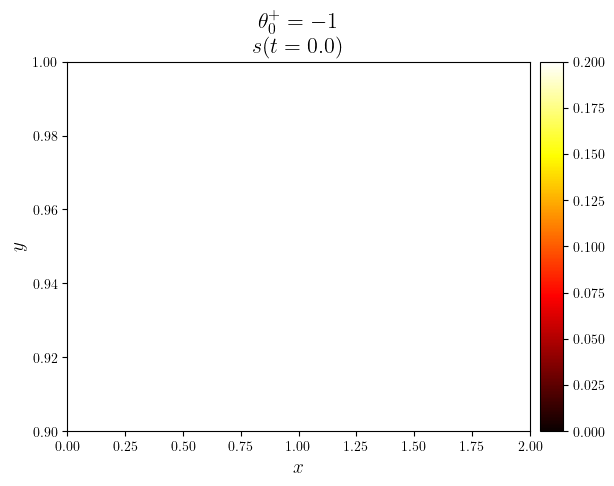

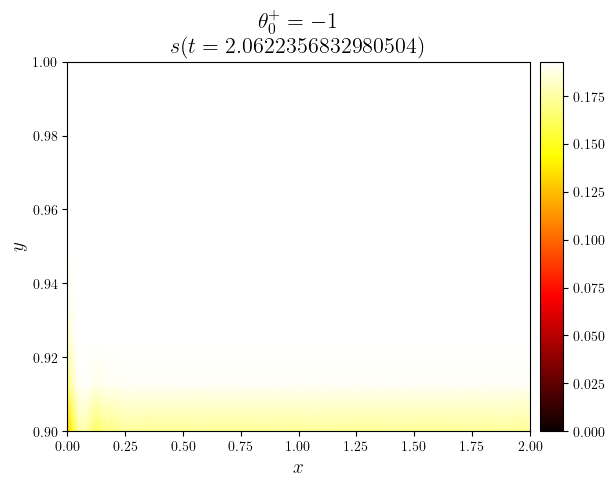

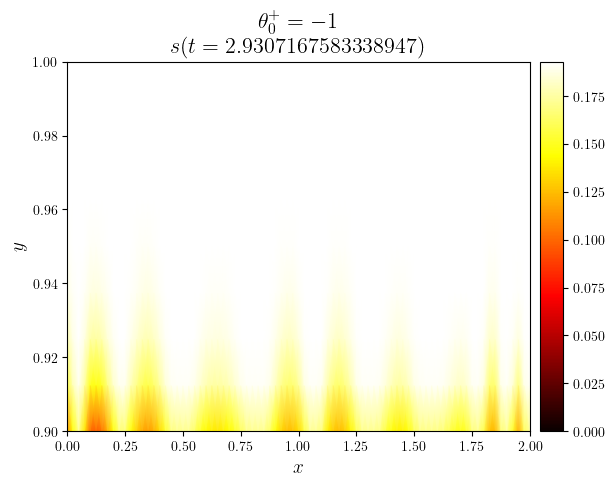

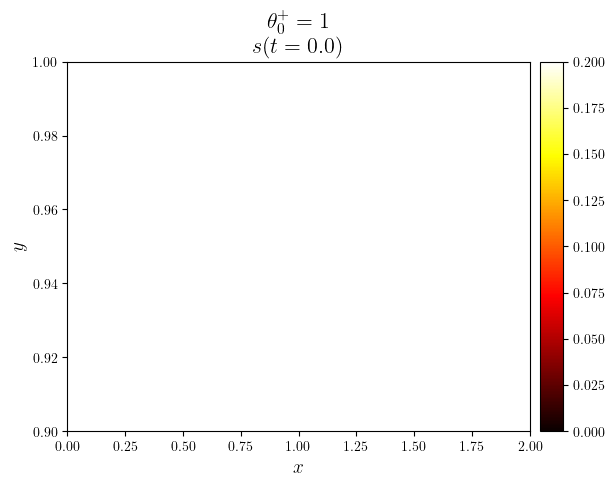

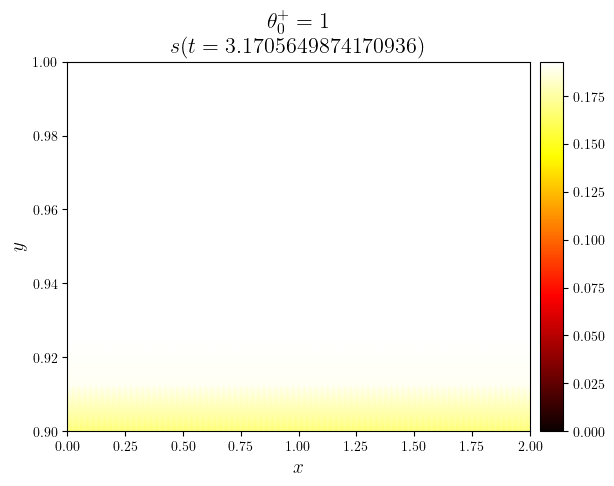

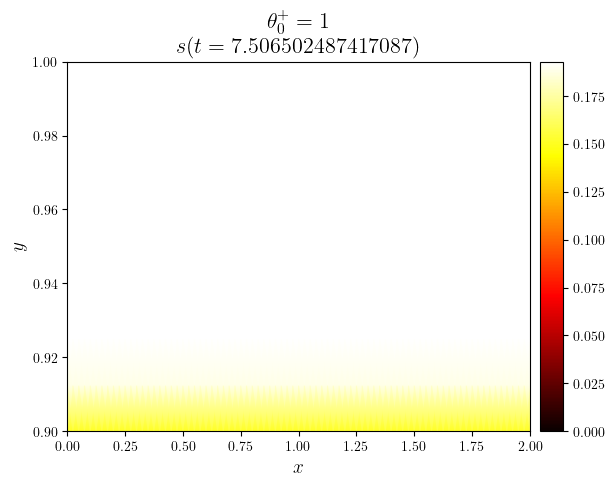

In [ ]:
index_targets = (0, 0.5, -1)

for theta_neg in theta_neg_opts:
    sim = simulations[theta_neg]
    s, zeta0, Ly = sim['s', 'zeta0', 'Ly']
    time_indices = as_index(s.time_series, index_targets, fraction=True)
    suptitle = title=theta_neg_title(theta_neg)
    for i in time_indices:
        fig, ax = plot_colormap(
            s.series[i], 
            y_lims=(zeta0 * Ly, Ly),
            title=f'{suptitle}\n$s(t={s.time_series[i]})$',
            aspect='auto',
        )

### Concentration

In [ ]:
index_targets = (0, 0.5, -1)

for theta_neg in theta_neg_opts:
    sim = simulations[theta_neg]
    c, zeta0, Ly = sim['c', 'zeta0', 'Ly']
    time_indices = as_index(c.time_series, index_targets, fraction=True)
    suptitle = title=theta_neg_title(theta_neg)
    for i in time_indices:
        fig, ax = plot_colormap(
            c.series[i], 
            title=f'{suptitle}\n$c(t={c.time_series[i]})$',
        )

### Temperature

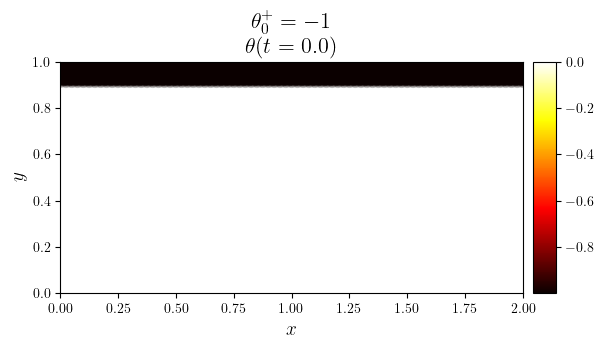

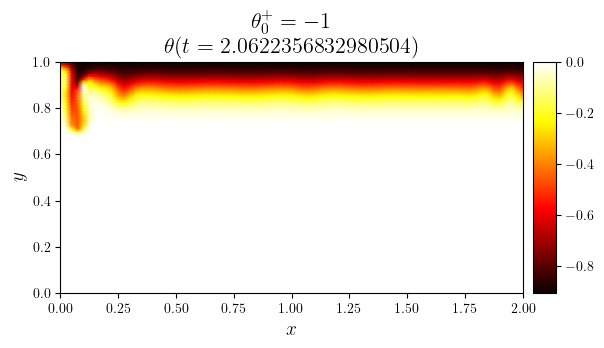

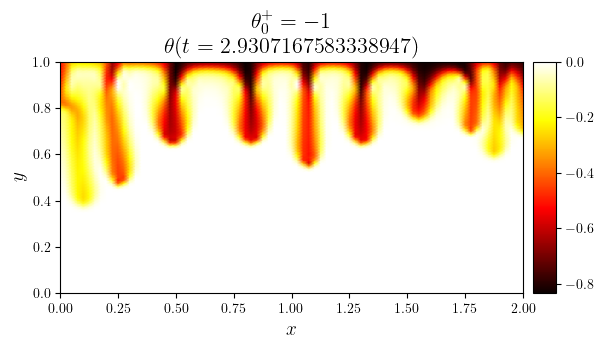

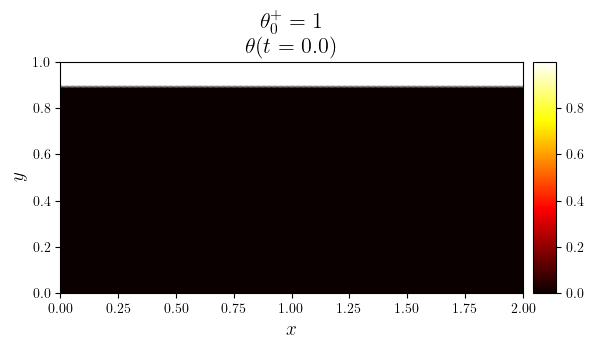

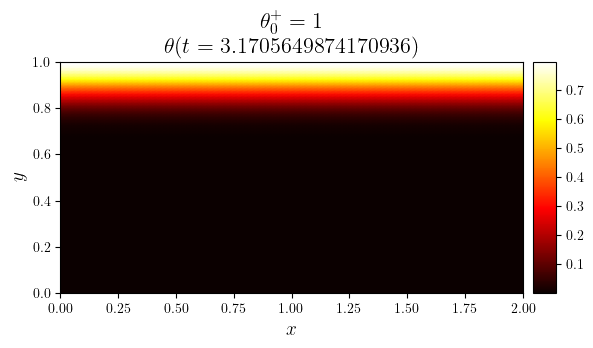

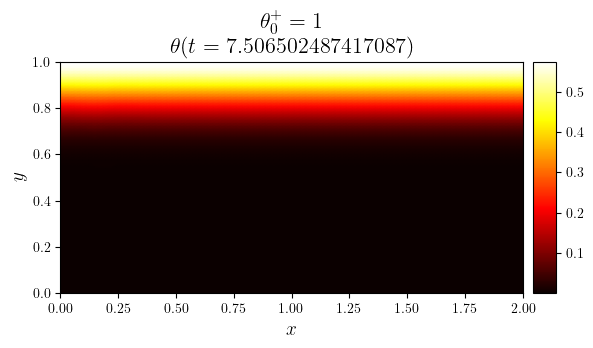

In [ ]:
index_targets = (0, 0.5, -1)

for theta_neg in theta_neg_opts:
    sim = simulations[theta_neg]
    theta, zeta0, Ly = sim['theta', 'zeta0', 'Ly']
    time_indices = as_index(theta.time_series, index_targets, fraction=True)
    suptitle = title=theta_neg_title(theta_neg)
    for i in time_indices:
        fig, ax = plot_colormap(
            theta.series[i], 
            title=f'{suptitle}\n$\\theta(t={theta.time_series[i]})$',
        )

## Numerical diagnostics

### Velocity norms

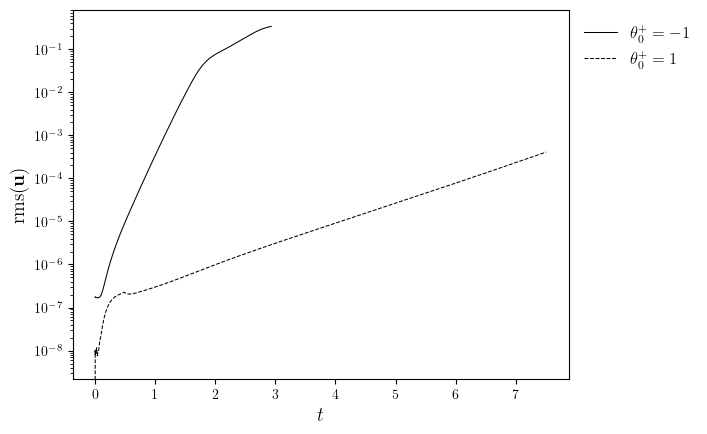

In [ ]:
uRMS_lines = []

for theta_neg in theta_neg_opts:
    sim = simulations[theta_neg]
    uRMS = sim['uRMS']
    uRMS_lines.append((uRMS.time_series, uRMS.value_series))

fig, ax = plot_line(
    uRMS_lines, 
    x_label='$t$', 
    y_label='$\mathrm{rms}(\mathbf{u})$', 
    legend_labels=[theta_neg_title(i) for i in theta_neg_opts],
)
ax.set_yscale('log')